In [1]:
%matplotlib inline
import numpy as np
import os
import pandas as pd
import glob
import japanize_matplotlib

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap
import seaborn as sns

from sklearn.metrics import confusion_matrix

from pywaffle import Waffle
from decimal import Decimal, ROUND_HALF_UP

# フィルタ用の混同行列用の要素計算

## コードテスト

In [2]:
# read result files
results = pd.read_csv('../data/231115FPRresults/task20over/FOLD_4_n=50_result_bugfixed.csv')
results

,Unnamed: 0,fpr_design,fpr_real,accuracy,precision,recall,f1,seed,Day
0,0,0.10,0.098923,0.777778,0.596951,0.450397,0.503085,100,14
1,1,0.15,0.144841,0.761243,0.545984,0.513889,0.522999,100,14
2,2,0.20,0.199830,0.724372,0.475377,0.525794,0.493333,100,14
3,3,0.25,0.254819,0.700893,0.444231,0.585317,0.500995,100,14
4,4,0.30,0.299036,0.675761,0.416842,0.613095,0.492707,100,14
...,...,...,...,...,...,...,...,...,...
3595,4,0.30,0.293367,0.697090,0.449537,0.676587,0.537768,149,38
3596,5,0.35,0.348639,0.671792,0.427648,0.736111,0.538384,149,38
3597,6,0.40,0.399660,0.660549,0.426364,0.839286,0.562035,149,38
3598,7,0.45,0.440760,0.640212,0.413289,0.876984,0.558798,149,38


In [3]:
# mean
results_mean = results.groupby(["fpr_design","Day"])[["fpr_real","accuracy","precision","recall","f1"]].mean().reset_index()
# dayからfpr_designの列だけ取得
results_meta = results_mean[["fpr_design","Day"]]
# 結合
results_bind = pd.concat([results_meta,results_mean],axis=1)
results_bind

,fpr_design,Day,fpr_design,Day,fpr_real,accuracy,precision,recall,f1
0,0.1,14,0.1,14,0.101020,0.762956,0.518355,0.383810,0.432109
1,0.1,17,0.1,17,0.101440,0.709656,0.331719,0.181190,0.229617
2,0.1,20,0.1,20,0.099972,0.744292,0.494417,0.310635,0.376255
3,0.1,24,0.1,24,0.100595,0.807794,0.629784,0.551310,0.579217
4,0.1,27,0.1,27,0.101332,0.761878,0.533934,0.378175,0.436138
...,...,...,...,...,...,...,...,...,...
67,0.5,24,0.5,24,0.497551,0.611577,0.395272,0.916429,0.550110
68,0.5,27,0.5,27,0.496746,0.587401,0.368578,0.822103,0.506663
69,0.5,31,0.5,31,0.498039,0.619332,0.403463,0.946627,0.563911
70,0.5,34,0.5,34,0.496576,0.619940,0.404136,0.945675,0.564158


混同行列の計算　

In [3]:
# fprate、accuracy、precision、recall、f1スコアを定義
fprate = 0.1
accuracy = 0.76
precision = 0.52
recall = 0.38
f1 = 0.43

# サンプルサイズとラベルを定義
sample_size = 34  # テストデータのサンプルサイズ
positive_label_count = 9  # ラベルが陽性であるサンプル数

# 混同行列の各要素を推定
TP = recall * positive_label_count
FP = fprate * (sample_size - positive_label_count)
TN = (1 - fprate) * (sample_size - positive_label_count)
FN = (1 - recall) * positive_label_count

# 推定した値を用いて混同行列を作成
conf_matrix = np.array([[TP, FP], [FN, TN]])

print("推定された混同行列:")
print(conf_matrix)

推定された混同行列:
[[ 3.42  2.5 ]
 [ 5.58 22.5 ]]


## 関数化

In [4]:
savefolder = "../data/231115FPRresults/"

# resultを読み込んで、TPTNFPFNのテーブルデータを作成
def mutate_confusion(row, task):
    if task == "task20over":
        positive_label_count = 9
        sample_size = 34
    elif task == "task10under":
        positive_label_count = 8
        sample_size = 34
    else:
        print("task名が間違っています")

    fprate = row.fpr_real
    recall = row.recall
    
    # 混同行列の各要素を推定
    TP = recall * positive_label_count
    FP = fprate * (sample_size - positive_label_count)
    TN = (1 - fprate) * (sample_size - positive_label_count)
    FN = (1 - recall) * positive_label_count

    # modelの効率を計算
    before_posi_rate = positive_label_count / sample_size
    if task == "task20over":
        after_posi_rate = TP / (TP + FP)
    elif task == "task10under":
        after_posi_rate = FN / (FN + TN)
    
    rate = after_posi_rate / before_posi_rate

    return pd.Series([TP, FP, TN, FN, rate])

def apply_conf(results_data, task):
    # mean
    results_mean = results_data.groupby(["fpr_design","Day"])[["fpr_real","accuracy","precision","recall","f1"]].mean().reset_index()
    # taskによって分岐
    if task == "task20over":
        # TPTNFPFNのテーブルデータを作成
        results_mean[["TP","FP","TN","FN","Positive rate change"]] = results_mean.apply(lambda row: mutate_confusion(row, task), axis=1)
    elif task == "task10under":
        # TPTNFPFNのテーブルデータを作成
        results_mean[["TP","FP","TN","FN","Impurity change"]] = results_mean.apply(lambda row: mutate_confusion(row, task), axis=1)
    else:
        print("task名が間違っています")
    
    # csvとして保存
    results_mean.to_csv(savefolder+task+"/result_add_conf.csv")
    return results_mean

In [5]:
res_20 = pd.read_csv('../data/231115FPRresults/task20over/FOLD_4_n=50_result_bugfixed.csv')
res_10 = pd.read_csv('../data/231115FPRresults/task10under/FOLD_4_n=50_result_bugfixed.csv')

res_20 = apply_conf(res_20, "task20over")
res_10 = apply_conf(res_10, "task10under")

In [6]:
res_20

,fpr_design,Day,fpr_real,accuracy,precision,recall,f1,TP,FP,TN,FN,Positive rate change
0,0.1,14,0.101020,0.762956,0.518355,0.383810,0.432109,3.454286,2.525510,22.474490,5.545714,2.182269
1,0.1,17,0.101440,0.709656,0.331719,0.181190,0.229617,1.630714,2.535998,22.464002,7.369286,1.478498
2,0.1,20,0.099972,0.744292,0.494417,0.310635,0.376255,2.795714,2.499291,22.500709,6.204286,1.994632
3,0.1,24,0.100595,0.807794,0.629784,0.551310,0.579217,4.961786,2.514881,22.485119,4.038214,2.507070
4,0.1,27,0.101332,0.761878,0.533934,0.378175,0.436138,3.403571,2.533305,22.466695,5.596429,2.165775
...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.5,24,0.497551,0.611577,0.395272,0.916429,0.550110,8.247857,12.438776,12.561224,0.752143,1.506218
68,0.5,27,0.496746,0.587401,0.368578,0.822103,0.506663,7.398929,12.418651,12.581349,1.601071,1.410440
69,0.5,31,0.498039,0.619332,0.403463,0.946627,0.563911,8.519643,12.450964,12.549036,0.480357,1.534782
70,0.5,34,0.496576,0.619940,0.404136,0.945675,0.564158,8.511071,12.414399,12.585601,0.488929,1.536545


In [7]:
res_10

,fpr_design,Day,fpr_real,accuracy,precision,recall,f1,TP,FP,TN,FN,Impurity change
0,0.1,14,0.100958,0.728013,0.285129,0.174524,0.212930,1.396190,2.624909,23.375091,6.603810,0.936198
1,0.1,17,0.099824,0.729246,0.313634,0.176905,0.223510,1.415238,2.595431,23.404569,6.584762,0.933173
2,0.1,20,0.100646,0.738869,0.347630,0.219286,0.264251,1.754286,2.616803,23.383197,6.245714,0.895891
3,0.1,24,0.100051,0.766644,0.455819,0.335000,0.381113,2.680000,2.601327,23.398673,5.320000,0.787293
4,0.1,27,0.101156,0.740883,0.332208,0.229048,0.265615,1.832381,2.630068,23.369932,6.167619,0.887426
...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.5,24,0.496854,0.589024,0.347699,0.867143,0.495831,6.937143,12.918197,13.081803,1.062857,0.319353
68,0.5,27,0.496366,0.585863,0.343890,0.851667,0.489399,6.813333,12.905522,13.094478,1.186667,0.353146
69,0.5,31,0.497954,0.566025,0.320666,0.773095,0.452601,6.184762,12.946791,13.053209,1.815238,0.518868
70,0.5,34,0.497517,0.546200,0.291811,0.688810,0.409106,5.510476,12.935442,13.064558,2.489524,0.680238


# 可視化用の作成

In [8]:
# 作図用のデータを作成
df_for_plot = res_20[["fpr_design","Day","TP","FP","TN","FN","Positive rate change"]].copy()
df_for_plot["task"] = "task20over"
df_for_plot["positive_label_count"] = 9
df_for_plot["sample_size"] = 34
df_for_plot

# 最大のPositive rate changeを持つデータを取得
df_top_prc = df_for_plot[df_for_plot["Positive rate change"] == df_for_plot["Positive rate change"].max()]
df_top_prc

,fpr_design,Day,TP,FP,TN,FN,Positive rate change,task,positive_label_count,sample_size
5,0.1,31,5.185,2.516156,22.483844,3.815,2.543485,task20over,9,34


## ワッフル

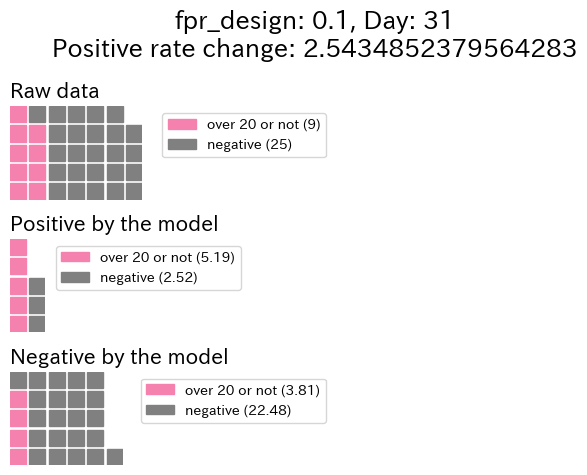

In [9]:
# 各種指標のvalueをdataから抜き出し
raw_posi = df_top_prc["positive_label_count"].values[0]
raw_nega = df_top_prc["sample_size"].values[0] - df_top_prc["positive_label_count"].values[0]
## 小数点第2位で四捨五入
model_TP = Decimal(df_top_prc["TP"].values[0]).quantize(Decimal('0.01'), rounding=ROUND_HALF_UP)
model_TN = Decimal(df_top_prc["TN"].values[0]).quantize(Decimal('0.01'), rounding=ROUND_HALF_UP)
model_FN = Decimal(df_top_prc["FN"].values[0]).quantize(Decimal('0.01'), rounding=ROUND_HALF_UP)
model_FP = Decimal(df_top_prc["FP"].values[0]).quantize(Decimal('0.01'), rounding=ROUND_HALF_UP)

# サブプロットの作成
fig, axs = plt.subplots(3, 1)

# Waffle プロットをサブプロットに追加
plot1 = Waffle.make_waffle(
    rows=5,
    values=[raw_posi, raw_nega],
    colors=["#f582ae", "gray"],
    labels=[f"over 20 or not ({raw_posi})", f"negative ({raw_nega})"],
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.1, 1)},
    title={'label': 'Raw data', 'loc': 'left', 'fontsize': 15},
    ax=axs[0]  # 最初のサブプロットにプロットを配置
)

plot2 = Waffle.make_waffle(
    rows=5,
    values=[model_TP, model_FP],
    colors=["#f582ae", "gray"],
    labels=[f"over 20 or not ({model_TP})", f"negative ({model_FP})"],
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.1, 1)},
    title={'label': 'Positive by the model', 'loc': 'left', 'fontsize': 15},
    ax=axs[1]  # 2番目のサブプロットにプロットを配置
)

plot3 = Waffle.make_waffle(
    rows=5,
    values=[model_FN, model_TN],
    colors=["#f582ae", "gray"],
    labels=[f"over 20 or not ({model_FN})", f"negative ({model_TN})"],
    legend={'loc': 'upper left', 'bbox_to_anchor': (1.1, 1)},
    title={'label': 'Negative by the model', 'loc': 'left', 'fontsize': 15},
    ax=axs[2]  # 3番目のサブプロットにプロットを配置
)
# アスペクト比を保つために、サブプロットごとに設定
for ax in axs.flatten():
    ax.set_aspect('equal')  # アスペクト比を1:1に保つ

# グラフのタイトルを追加。fpr_designとDayとPositive rate changeを表示
# fpr_designとDayの後で改行
fig.suptitle("fpr_design: "+str(df_top_prc["fpr_design"].values[0])+", Day: "+str(df_top_prc["Day"].values[0])+"\n"+"Positive rate change: "+str(df_top_prc["Positive rate change"].values[0]), fontsize=18)
plt.tight_layout()  # レイアウトの調整
plt.show()

## 関数化

In [10]:
def plot_waffle(dat, task, fpr_design, day, view=False, scale=True):   
    df_target = dat[(dat["fpr_design"] == fpr_design) & (dat["Day"] == day)]
    df_target = df_target.reset_index(drop=True)

    # taskによって分岐
    if task == "task20over":
        raw_posi = 9
    
        score_title = "Positive rate change"
        score = Decimal(df_target["Positive rate change"].values[0]).quantize(Decimal('0.01'), rounding=ROUND_HALF_UP)
    elif task == "task10under":
        raw_posi = 8
        
        score_title = "Impurity change"
        score = Decimal(df_target["Impurity change"].values[0]).quantize(Decimal('0.01'), rounding=ROUND_HALF_UP)

    # 各種指標のvalueをdataから抜き出し
    raw_nega = 34 - raw_posi
    ## 小数点第2位で四捨五入
    model_TP = Decimal(df_target["TP"].values[0]).quantize(Decimal('0.01'), rounding=ROUND_HALF_UP)
    model_TN = Decimal(df_target["TN"].values[0]).quantize(Decimal('0.01'), rounding=ROUND_HALF_UP)
    model_FN = Decimal(df_target["FN"].values[0]).quantize(Decimal('0.01'), rounding=ROUND_HALF_UP)
    model_FP = Decimal(df_target["FP"].values[0]).quantize(Decimal('0.01'), rounding=ROUND_HALF_UP)

    # taskによる分岐
    if task == "task20over":
        pl_col = ["#f582ae", "gray"]
        title = "MYF5+% score > 20"
    elif task == "task10under":
        pl_col = ["#8bd3dd", "gray"]
        title = "MYF5+% score < 10"
    else:
        print("task名が間違っています")

    # scaleがTrueの場合は、TP,FP,FN,TNの値を合計して100%にする
    if scale:
        total = model_TP + model_FP + model_FN + model_TN
        # 小数点第1位で四捨五入
        model_TP = Decimal(model_TP / total * 100).quantize(Decimal('0.1'), rounding=ROUND_HALF_UP)
        model_FP = Decimal(model_FP / total * 100).quantize(Decimal('0.1'), rounding=ROUND_HALF_UP)
        model_FN = Decimal(model_FN / total * 100).quantize(Decimal('0.1'), rounding=ROUND_HALF_UP)
        model_TN = Decimal(model_TN / total * 100).quantize(Decimal('0.1'), rounding=ROUND_HALF_UP)
        # raw_posi, raw_negaも合計して100%にする
        total = raw_posi + raw_nega
        raw_posi = Decimal(raw_posi / total * 100).quantize(Decimal('0.1'), rounding=ROUND_HALF_UP)
        raw_nega = Decimal(raw_nega / total * 100).quantize(Decimal('0.1'), rounding=ROUND_HALF_UP)        

    return just_plot_waffle(pl_col,title,
                fpr_design, day, score_title, score,
                raw_posi, raw_nega, model_TP, model_FP, model_FN, model_TN,
                view=view)

def just_plot_waffle(pl_col,title,
                fpr_design, day, score_title, score,
                raw_posi, raw_nega, model_TP, model_FP, model_FN, model_TN,
                view=False):
    # サブプロットの作成
    fig, axs = plt.subplots(3, 1)
    # Waffle プロットをサブプロットに追加
    plot1 = Waffle.make_waffle(
        rows=5,
        values=[raw_posi, raw_nega],
        colors=pl_col,
        labels=[f"{title} ({raw_posi})", f"negative ({raw_nega})"],
        legend={'loc': 'upper left', 'bbox_to_anchor': (1.1, 1)},
        title={'label': 'Raw data', 'loc': 'left', 'fontsize': 15},
        ax=axs[0]  # 最初のサブプロットにプロットを配置
    )

    plot2 = Waffle.make_waffle(
        rows=5,
        values=[model_TP, model_FP],
        colors=pl_col,
        labels=[f"{title} ({model_TP})", f"negative ({model_FP})"],
        legend={'loc': 'upper left', 'bbox_to_anchor': (1.1, 1)},
        title={'label': 'Positive by the model', 'loc': 'left', 'fontsize': 15},
        ax=axs[1]  # 2番目のサブプロットにプロットを配置
    )

    plot3 = Waffle.make_waffle(
        rows=5,
        values=[model_FN, model_TN],
        colors=pl_col,
        labels=[f"{title} ({model_FN})", f"negative ({model_TN})"],
        legend={'loc': 'upper left', 'bbox_to_anchor': (1.1, 1)},
        title={'label': 'Negative by the model', 'loc': 'left', 'fontsize': 15},
        ax=axs[2]  # 3番目のサブプロットにプロットを配置
    )

    # アスペクト比を保つために、サブプロットごとに設定
    for ax in axs.flatten():
        ax.set_aspect('equal')  # アスペクト比を1:1に保つ
    
    # グラフのタイトルを追加。fpr_designとDayとPositive rate changeを表示
    # fpr_designとDayの後で改行
    fig.suptitle(f"fpr_design: {fpr_design}, Day: {day}\n{score_title}: {score}",
                 fontsize=18,
                 x=0.3,y=0.95)
    plt.tight_layout()  # レイアウトの調整
    if view:
        plt.show()
    else:
        plt.close()
    return fig

In [16]:
res_20[res_20["Positive rate change"] == res_20["Positive rate change"].max()]

,fpr_design,Day,fpr_real,accuracy,precision,recall,f1,TP,FP,TN,FN,Positive rate change
5,0.1,31,0.100646,0.814385,0.646939,0.576111,0.602017,5.185,2.516156,22.483844,3.815,2.543485


In [17]:
res_10[res_10["Impurity change"] == res_10["Impurity change"].min()]

,fpr_design,Day,fpr_real,accuracy,precision,recall,f1,TP,FP,TN,FN,Impurity change
67,0.5,24,0.496854,0.589024,0.347699,0.867143,0.495831,6.937143,12.918197,13.081803,1.062857,0.319353


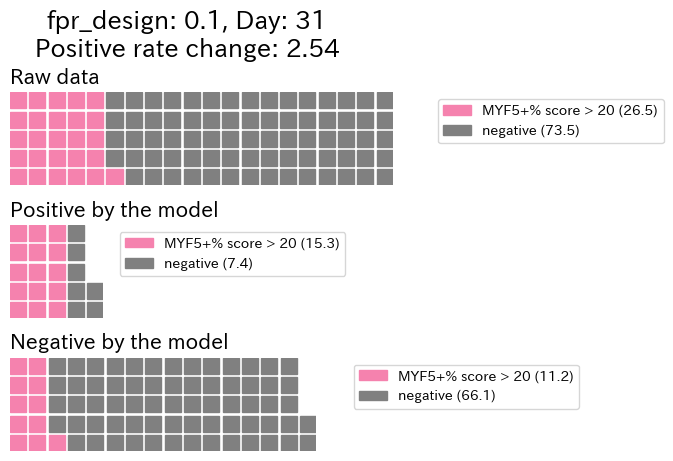

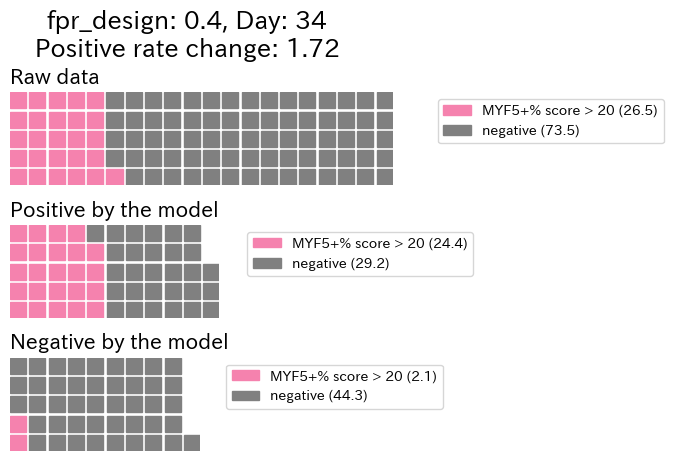

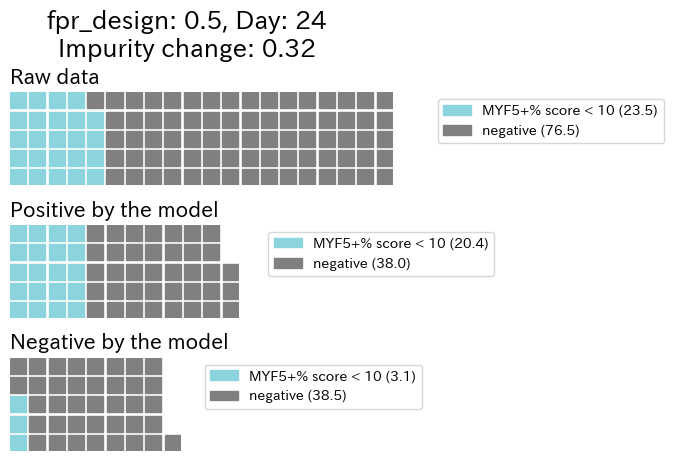

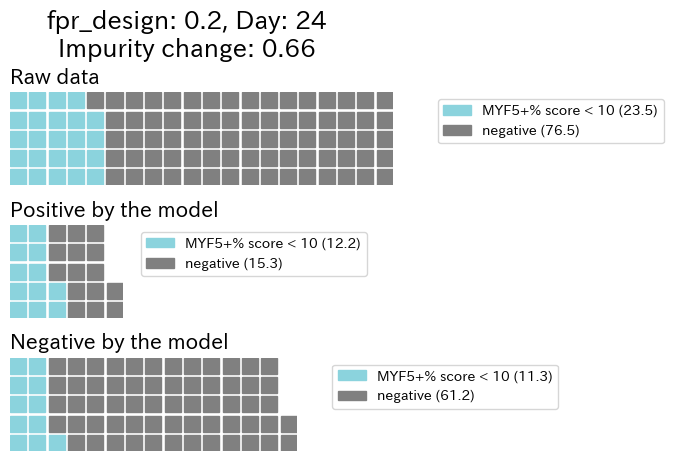

In [13]:
fig_best_20 = plot_waffle(res_20, "task20over", 0.1, 31, view=True)
fig_best_20.savefig(savefolder+"task20over/waffle_0.1_31.svg", dpi=300, bbox_inches="tight")

fig_20 = plot_waffle(res_20, "task20over", 0.4, 34, view=True)
fig_20.savefig(savefolder+"task20over/waffle_0.4_34.svg", dpi=300, bbox_inches="tight")

fig_best_10 = plot_waffle(res_10, "task10under", 0.5, 24, view=True)
fig_best_10.savefig(savefolder+"task10under/waffle_0.1_31.svg", dpi=300, bbox_inches="tight")

fig_10 = plot_waffle(res_10, "task10under", 0.2, 24, view=True)
fig_10.savefig(savefolder+"task10under/waffle_0.2_24.svg", dpi=300, bbox_inches="tight")

In [14]:
# 全てのdayとfpr_designの組み合わせについてwaffle plotを作成
def create_waffle_all(dat, task):
    # fpr_designとDayの組み合わせを取得
    fpr_design_list = dat["fpr_design"].unique()
    day_list = dat["Day"].unique()
    # 保存先のフォルダを作成
    os.makedirs(savefolder+task+"/waffle/", exist_ok=True)
    os.makedirs(savefolder+task+"/waffle_scaled/", exist_ok=True)
    # 作図
    for fpr_design in fpr_design_list:
        for day in day_list:
            fig = plot_waffle(dat, task, fpr_design, day, scale=False)
            fig.savefig(savefolder+task+"/waffle/"+str(fpr_design)+"_"+str(day)+".svg", dpi=300)
            fig = plot_waffle(dat, task, fpr_design, day, scale=True)
            fig.savefig(savefolder+task+"/waffle_scaled/"+str(fpr_design)+"_"+str(day)+"_scaled.svg", dpi=300, bbox_inches="tight")

In [15]:
create_waffle_all(res_20, "task20over")
create_waffle_all(res_10, "task10under")